# Customer Churn Analysis
**Author:** Shubham Kumar Dubey  
**Dataset:** customer_churn_dataset.csv  
**Objective:** Predict whether a customer will churn using machine learning models and provide actionable business insights through exploratory data analysis.

---
### Table of Contents
1. [Import Libraries](#1)
2. [Load & Inspect Dataset](#2)
3. [Exploratory Data Analysis (EDA)](#3)
4. [Data Preprocessing](#4)
5. [Model Building](#5)
6. [Model Evaluation & Comparison](#6)
7. [Feature Importance](#7)
8. [Business Insights & Recommendations](#8)
9. [Predict on New Customer](#9)

---
## 1. Import Libraries <a id='1'></a>

In [ ]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Imbalanced data
from imblearn.over_sampling import SMOTE

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
CHURN_COLORS = ['#3b82d4', '#e05c5c']
print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load & Inspect Dataset <a id='2'></a>

In [ ]:
df = pd.read_csv('customer_churn_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head(10)

Dataset shape: (64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0
5,6,30,Male,41,14,10,10,Premium,Monthly,500,29,0
6,7,47,Female,37,15,9,28,Basic,Quarterly,574,14,1
7,8,54,Female,36,11,0,18,Standard,Monthly,323,16,0
8,9,36,Male,20,5,10,8,Basic,Monthly,687,8,0
9,10,65,Male,8,4,2,23,Basic,Annual,995,10,0


In [ ]:
print('--- Data Types & Non-Null Counts ---')
df.info()

--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         64374 non-null  int64
 1   Age                64374 non-null  int64
 2   Gender             64374 non-null  str  
 3   Tenure             64374 non-null  int64
 4   Usage Frequency    64374 non-null  int64
 5   Support Calls      64374 non-null  int64
 6   Payment Delay      64374 non-null  int64
 7   Subscription Type  64374 non-null  str  
 8   Contract Length    64374 non-null  str  
 9   Total Spend        64374 non-null  int64
 10  Last Interaction   64374 non-null  int64
 11  Churn              64374 non-null  int64
dtypes: int64(9), str(3)
memory usage: 7.1 MB


In [ ]:
print('--- Descriptive Statistics ---')
df.describe(include='all').T

--- Descriptive Statistics ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,64374.0,NaN,NaN,NaN,32187.5,18583.317451,1.0,16094.25,32187.5,48280.75,64374.0
Age,64374.0,NaN,NaN,NaN,41.970982,13.924911,18.0,30.0,42.0,54.0,65.0
Gender,64374,2,Female,34353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,64374.0,NaN,NaN,NaN,31.994827,17.098234,1.0,18.0,33.0,47.0,60.0
Usage Frequency,64374.0,NaN,NaN,NaN,15.080234,8.81647,1.0,7.0,15.0,23.0,30.0
Support Calls,64374.0,NaN,NaN,NaN,5.40069,3.114005,0.0,3.0,6.0,8.0,10.0
Payment Delay,64374.0,NaN,NaN,NaN,17.133952,8.852211,0.0,10.0,19.0,25.0,30.0
Subscription Type,64374,3,Standard,21502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Contract Length,64374,3,Monthly,22130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,64374.0,NaN,NaN,NaN,541.023379,260.874809,100.0,313.0,534.0,768.0,1000.0


In [ ]:
print('--- Missing Values ---')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

--- Missing Values ---
No missing values found.


In [ ]:
print('--- Duplicate Rows ---')
print(f'Duplicate rows: {df.duplicated().sum()}')

print('\n--- Target Distribution ---')
print(df['Churn'].value_counts())
print(f'Churn Rate: {df["Churn"].mean()*100:.2f}%')

--- Duplicate Rows ---
Duplicate rows: 0

--- Target Distribution ---
Churn
0    33881
1    30493
Name: count, dtype: int64
Churn Rate: 47.37%


---
## 3. Exploratory Data Analysis (EDA) <a id='3'></a>

### 3.1 Target Variable Distribution

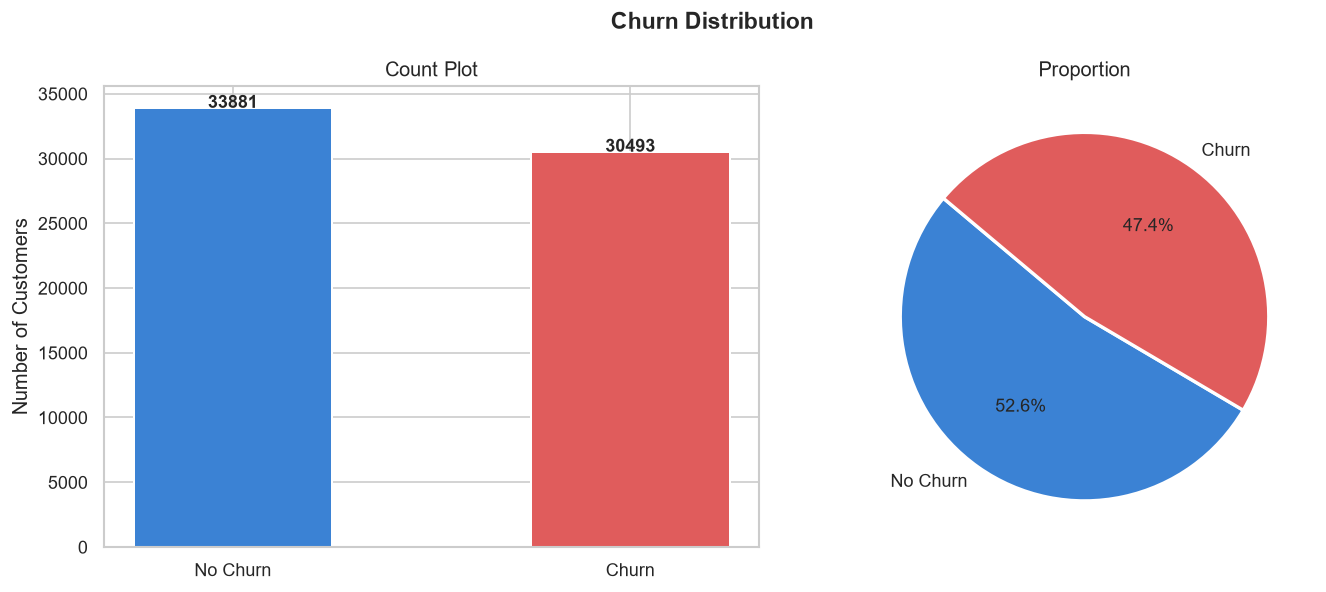

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold')

counts = df['Churn'].value_counts()
labels = ['No Churn', 'Churn']

axes[0].bar(labels, counts, color=CHURN_COLORS, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Count Plot')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=CHURN_COLORS,
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')
plt.tight_layout()
plt.savefig('churn_distribution.png', bbox_inches='tight')
plt.show()

### 3.2 Numerical Features Distribution

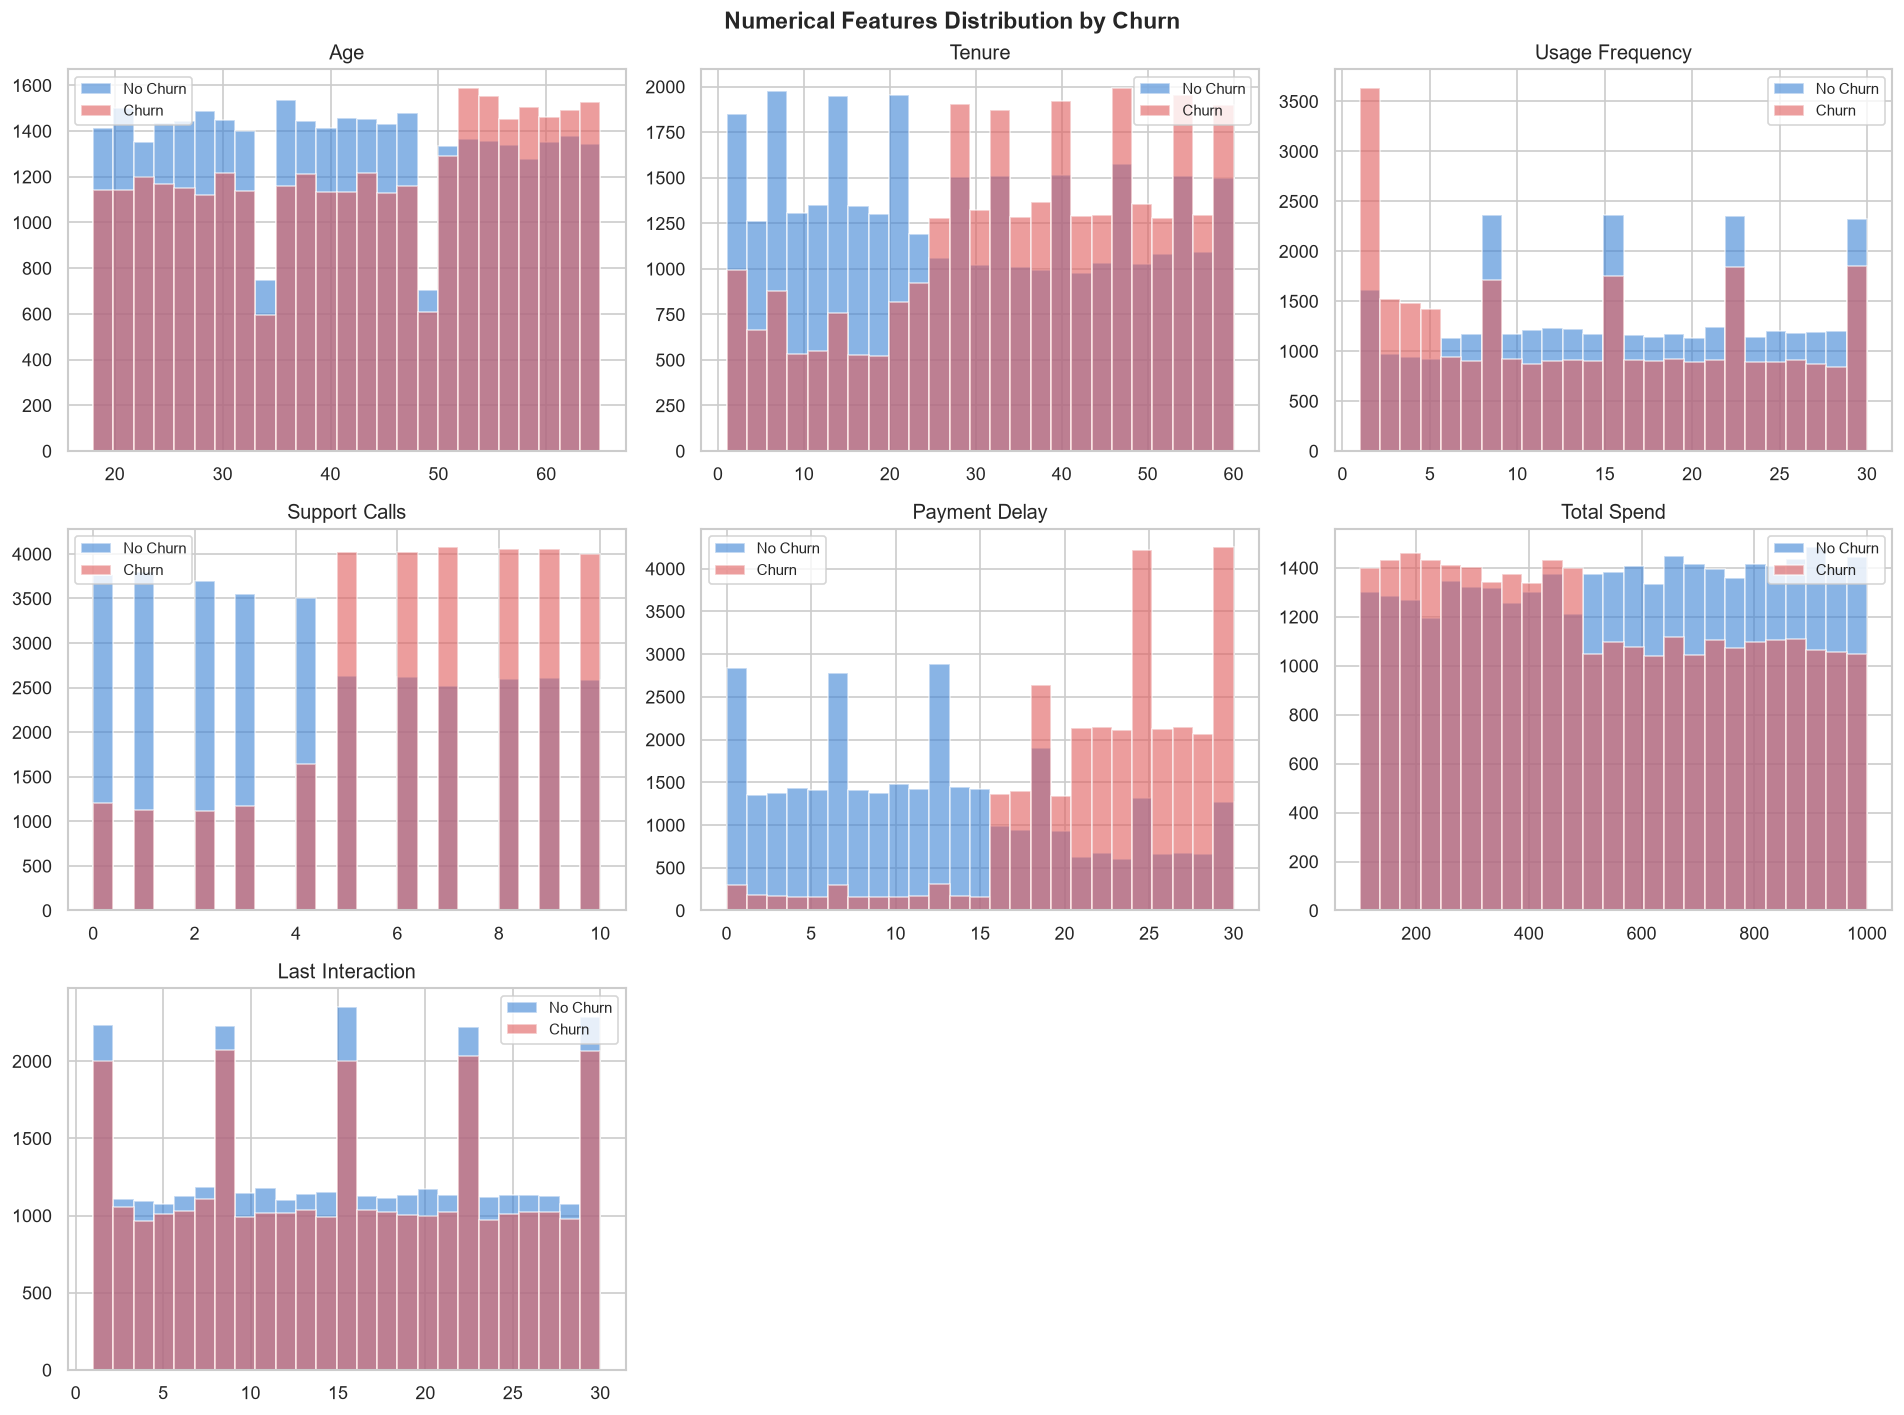

In [ ]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Numerical Features Distribution by Churn', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for churn_val, color, label in zip([0, 1], CHURN_COLORS, ['No Churn', 'Churn']):
        axes[i].hist(df[df['Churn'] == churn_val][col], bins=25, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(col)
    axes[i].legend(fontsize=9)
    axes[i].set_xlabel('')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('numerical_distributions.png', bbox_inches='tight')
plt.show()

### 3.3 Categorical Features vs Churn

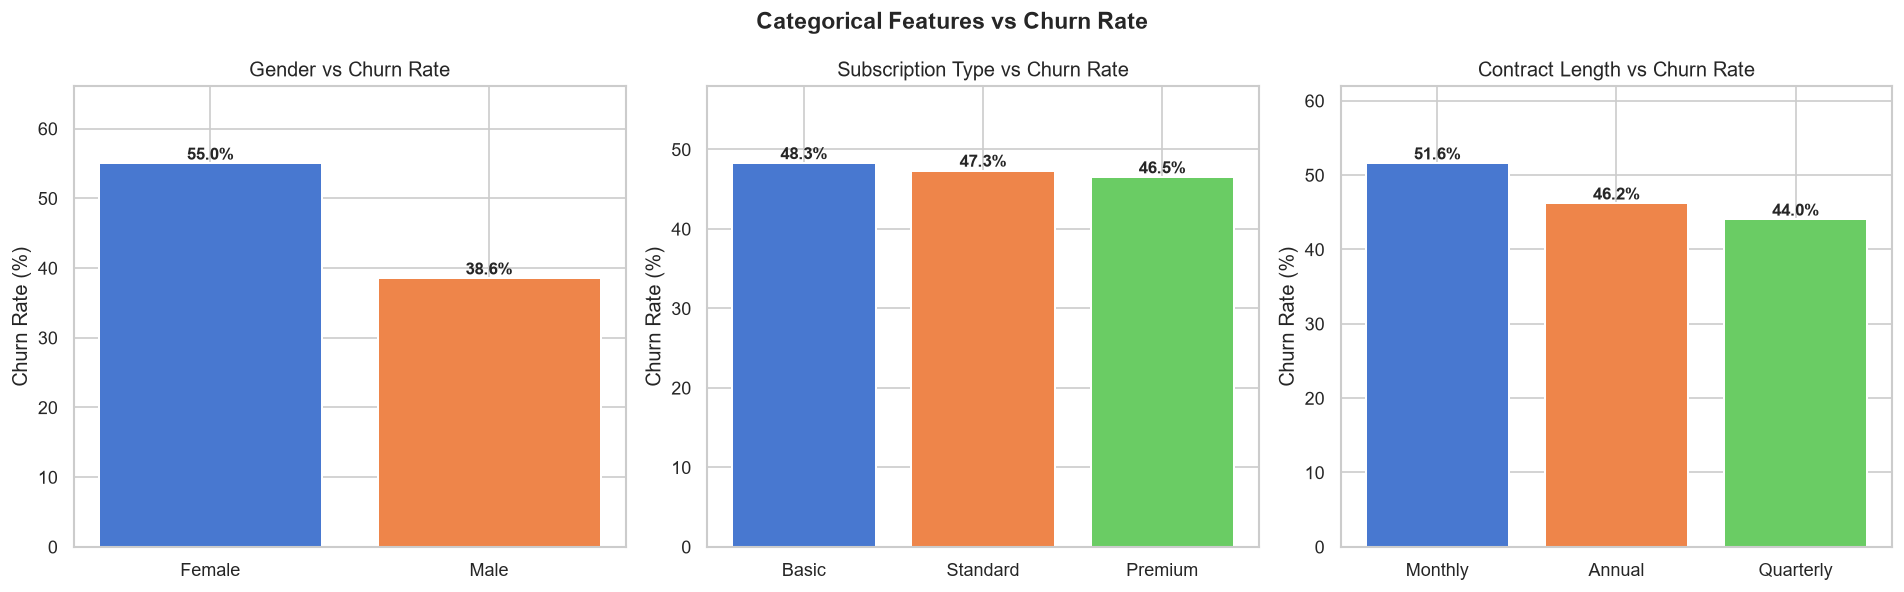

In [ ]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Categorical Features vs Churn Rate', fontsize=14, fontweight='bold')

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = axes[i].bar(churn_rate.index, churn_rate.values * 100,
                       color=sns.color_palette('muted', len(churn_rate)),
                       edgecolor='white', linewidth=1.2)
    axes[i].set_title(f'{col} vs Churn Rate')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, churn_rate.max() * 120)
    for bar, val in zip(bars, churn_rate.values * 100):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.5, f'{val:.1f}%',
                     ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('categorical_vs_churn.png', bbox_inches='tight')
plt.show()

### 3.4 Correlation Heatmap

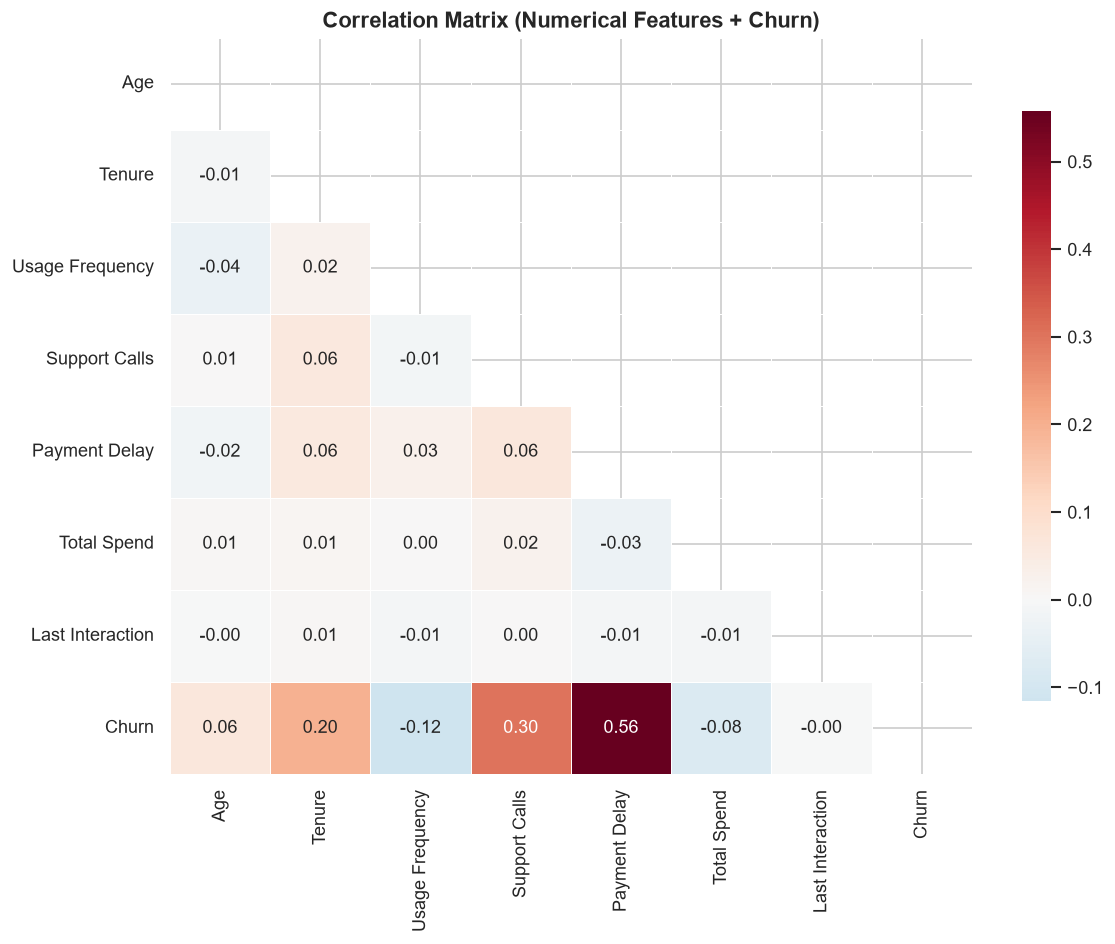

In [ ]:
df_corr = df[num_cols + ['Churn']].copy()
corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (Numerical Features + Churn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 3.5 Box Plots — Key Features vs Churn

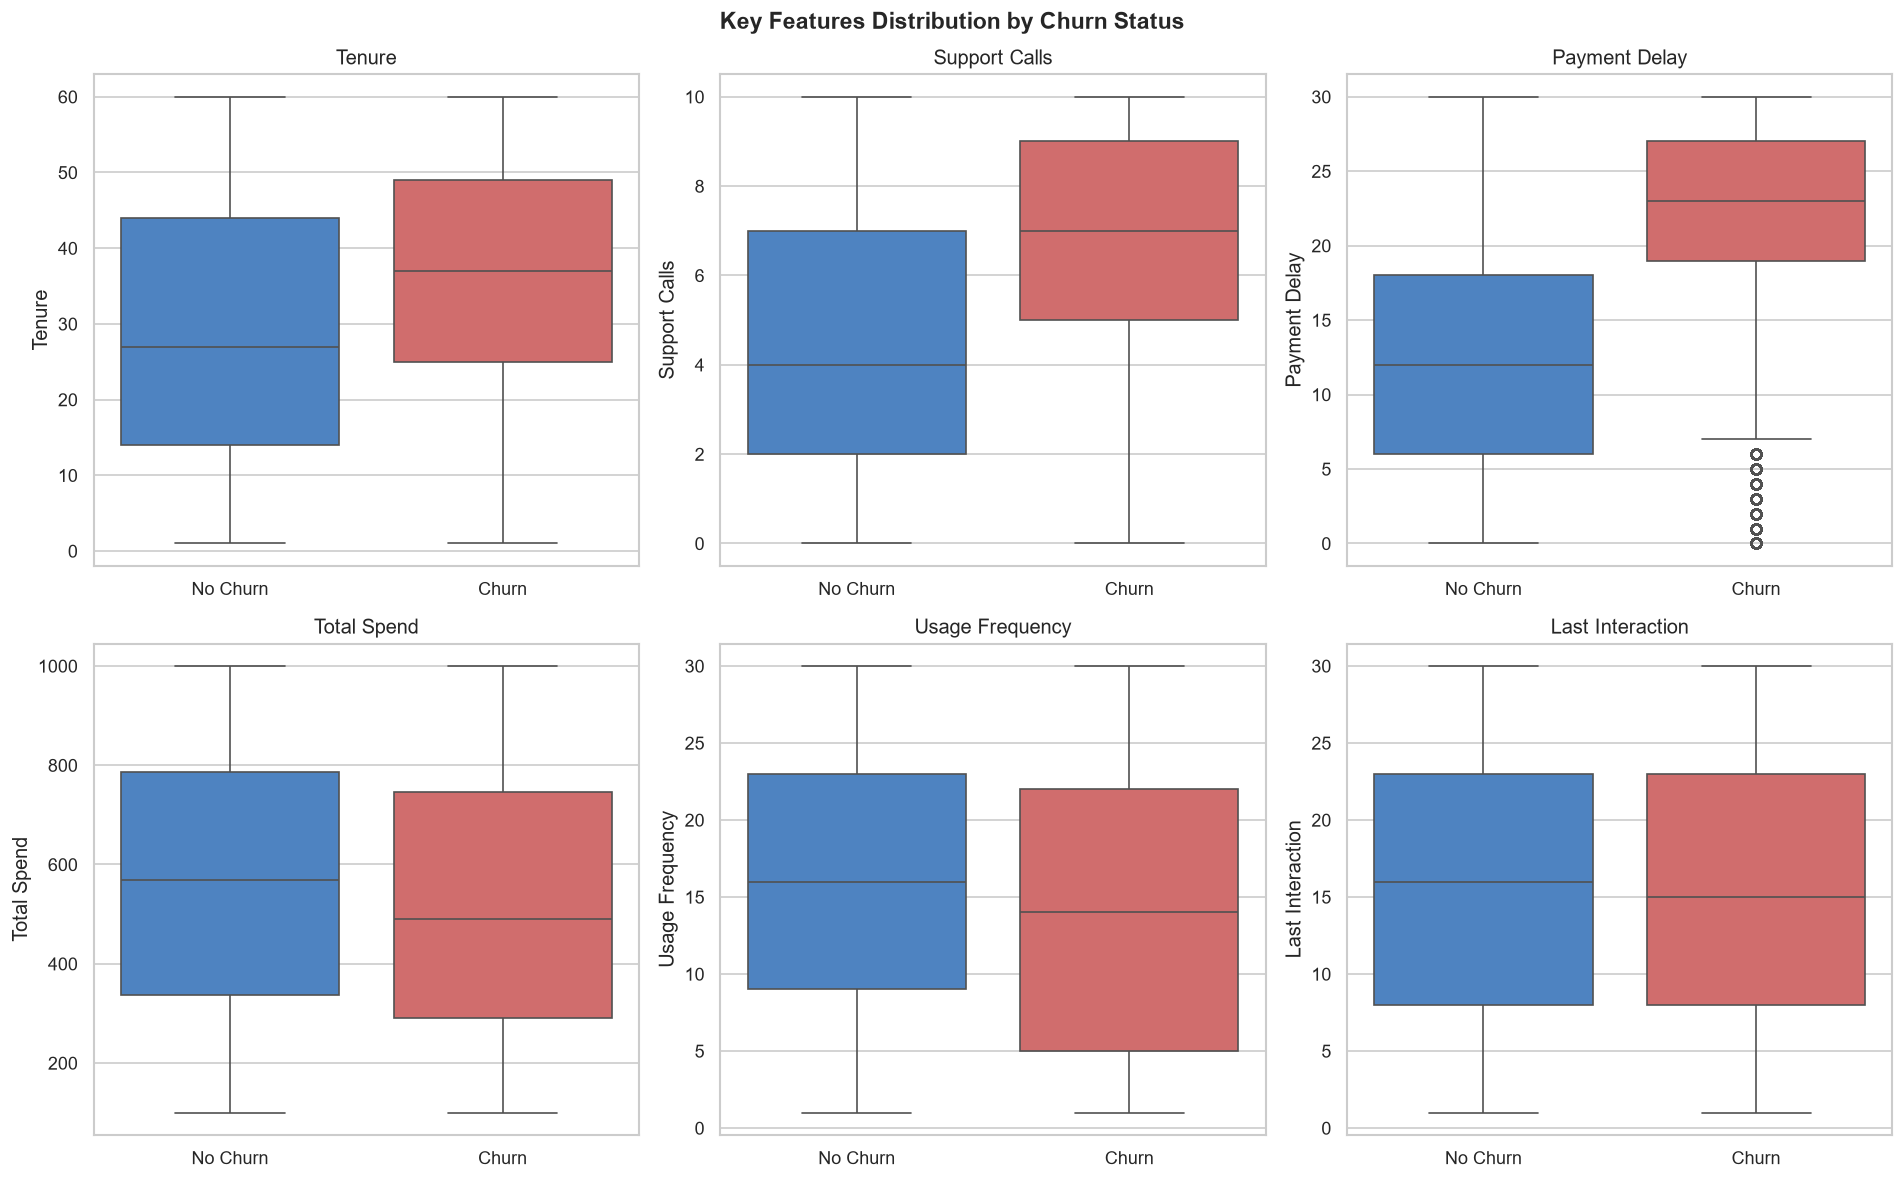

In [ ]:
key_features = ['Tenure', 'Support Calls', 'Payment Delay', 'Total Spend', 'Usage Frequency', 'Last Interaction']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Key Features Distribution by Churn Status', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[i],
                palette={'0': CHURN_COLORS[0], '1': CHURN_COLORS[1]})
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])
    axes[i].set_xlabel('')
plt.tight_layout()
plt.savefig('boxplots_churn.png', bbox_inches='tight')
plt.show()

### 3.6 Churn Rate by Subscription Type & Contract Length

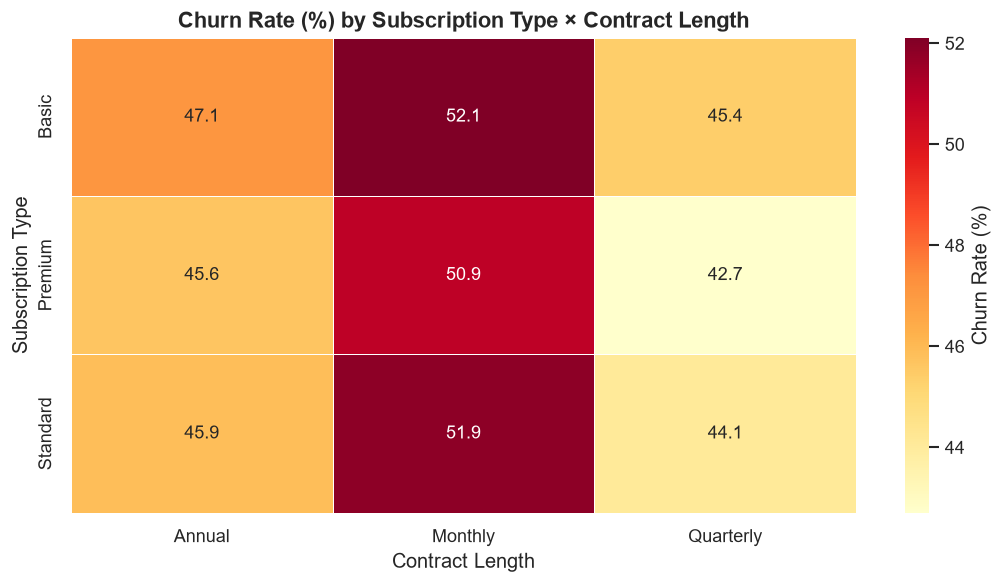

In [ ]:
pivot = df.pivot_table(values='Churn', index='Subscription Type',
                       columns='Contract Length', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Churn Rate (%)'})
ax.set_title('Churn Rate (%) by Subscription Type × Contract Length',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('churn_heatmap_sub_contract.png', bbox_inches='tight')
plt.show()

---
## 4. Data Preprocessing <a id='4'></a>

In [ ]:
df_model = df.copy()

# Drop CustomerID — not a feature
df_model.drop(columns=['CustomerID'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_encode = ['Gender', 'Subscription Type', 'Contract Length']
for col in cat_encode:
    df_model[col] = le.fit_transform(df_model[col])
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('\nPreprocessed shape:', df_model.shape)
df_model.head()

Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
Subscription Type: {'Basic': np.int64(0), 'Premium': np.int64(1), 'Standard': np.int64(2)}
Contract Length: {'Annual': np.int64(0), 'Monthly': np.int64(1), 'Quarterly': np.int64(2)}

Preprocessed shape: (64374, 11)


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,0,25,14,4,27,0,1,598,9,1
1,41,0,28,28,7,13,2,1,584,20,0
2,47,1,27,10,2,29,1,0,757,21,0
3,35,1,9,12,5,17,1,2,232,18,0
4,53,0,58,24,9,2,2,0,533,18,0


In [ ]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f'Features: {X.shape[1]}  |  Samples: {X.shape[0]}')
print(f'Class distribution before SMOTE:\n{y.value_counts()}')

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(f'\nClass distribution after SMOTE:\n{pd.Series(y_res).value_counts()}')

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print(f'\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Feature scaling done.')

Features: 10  |  Samples: 64374
Class distribution before SMOTE:
Churn
0    33881
1    30493
Name: count, dtype: int64



Class distribution after SMOTE:
Churn
1    33881
0    33881
Name: count, dtype: int64

Train size: 54209  |  Test size: 13553
Feature scaling done.


---
## 5. Model Building <a id='5'></a>

In [ ]:
models = {
    'Logistic Regression'      : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'            : DecisionTreeClassifier(random_state=42),
    'Random Forest'            : RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting'        : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'AdaBoost'                 : AdaBoostClassifier(n_estimators=100, random_state=42),
    'XGBoost'                  : XGBClassifier(n_estimators=200,
                                                eval_metric='logloss', random_state=42),
    'KNN'                      : KNeighborsClassifier(n_neighbors=5),
    'SVM'                      : SVC(probability=True, random_state=42)
}

# Use scaled data for models that require it; raw for tree-based
scale_required = {'Logistic Regression', 'KNN', 'SVM'}

results = []
trained_models = {}

for name, model in models.items():
    Xtr = X_train_sc if name in scale_required else X_train
    Xte = X_test_sc  if name in scale_required else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    results.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1 Score'  : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_prob), 4)
    })
    trained_models[name] = (model, Xte)
    print(f'[✓] {name}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print('\n--- Model Comparison ---')
results_df

[✓] Logistic Regression


[✓] Decision Tree


[✓] Random Forest


[✓] Gradient Boosting


[✓] AdaBoost


[✓] XGBoost


[✓] KNN


[✓] SVM

--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.9983,0.9994,0.9972,0.9983,0.9999
1,Random Forest,0.9979,0.9991,0.9966,0.9979,0.9998
2,Gradient Boosting,0.9971,0.9991,0.9951,0.9971,0.9997
3,Decision Tree,0.9955,0.9944,0.9966,0.9955,0.9955
4,SVM,0.9441,0.9286,0.9622,0.9451,0.9897
5,KNN,0.9140,0.8867,0.9492,0.9169,0.9694
6,AdaBoost,0.8806,0.8702,0.8946,0.8823,0.9499
7,Logistic Regression,0.8255,0.8192,0.8353,0.8272,0.9025


---
## 6. Model Evaluation & Comparison <a id='6'></a>

### 6.1 Performance Comparison Chart

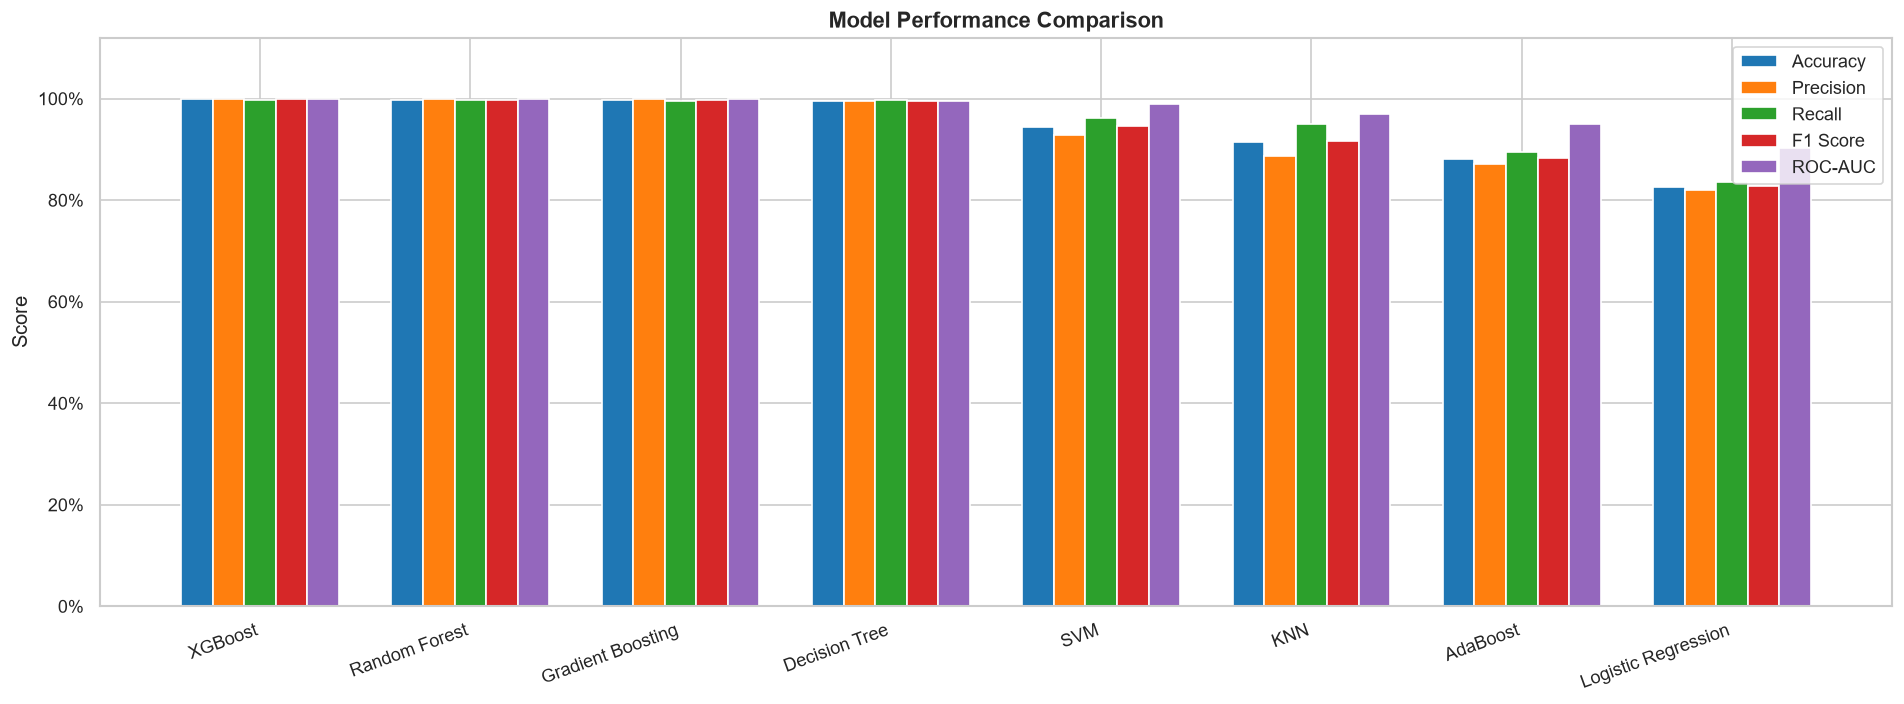

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x = np.arange(len(results_df))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 6))
palette = sns.color_palette('tab10', len(metrics))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric,
           color=palette[i], edgecolor='white')

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

### 6.2 ROC Curves

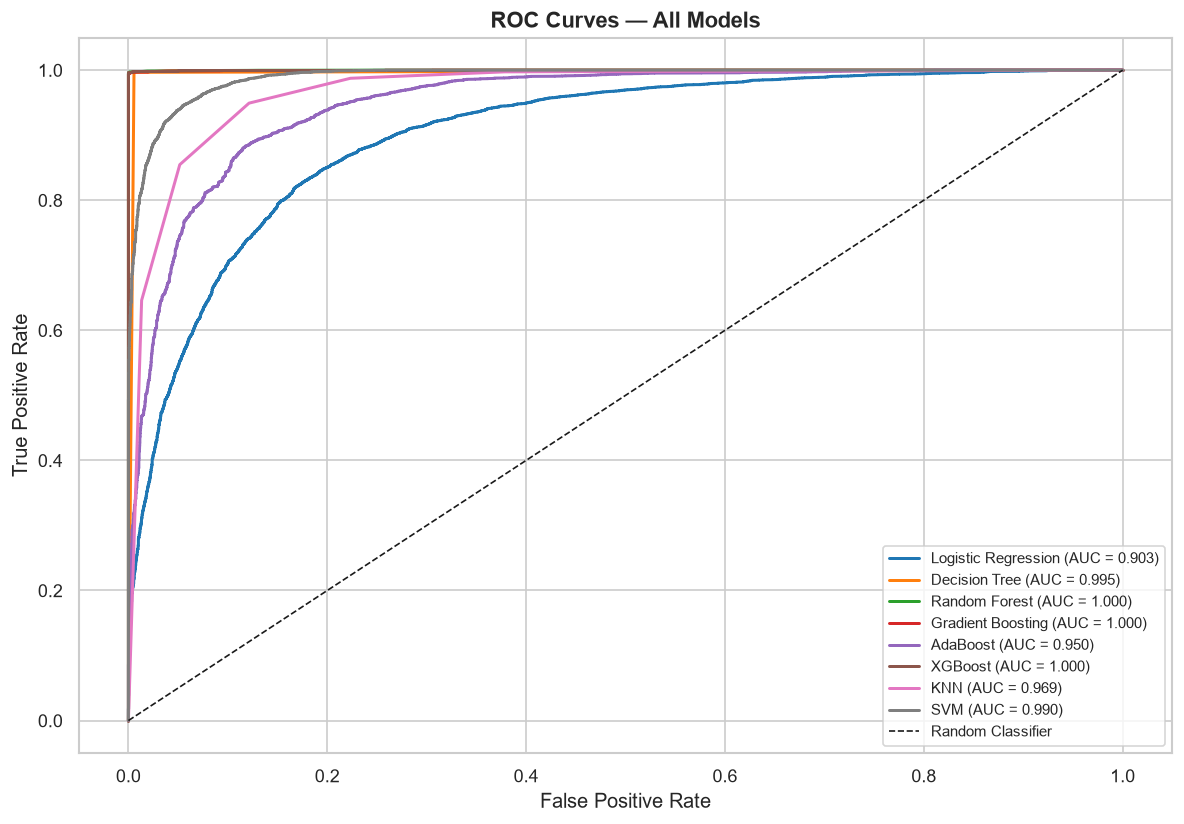

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
palette_roc = sns.color_palette('tab10', len(models))

for i, (name, (model, Xte)) in enumerate(trained_models.items()):
    y_prob = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=palette_roc[i], lw=1.8, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

### 6.3 Best Model — Confusion Matrix & Classification Report

Best Model: XGBoost
ROC-AUC : 0.9999
Accuracy: 0.9983
F1 Score: 0.9983

Classification Report:

              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00      6777
       Churn       1.00      1.00      1.00      6776

    accuracy                           1.00     13553
   macro avg       1.00      1.00      1.00     13553
weighted avg       1.00      1.00      1.00     13553



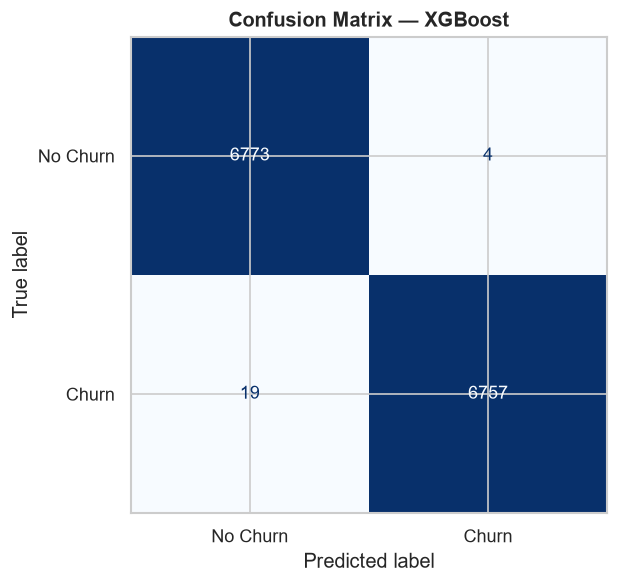

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model, best_Xte = trained_models[best_model_name]
y_pred_best = best_model.predict(best_Xte)

print(f'Best Model: {best_model_name}')
print(f'ROC-AUC : {results_df.iloc[0]["ROC-AUC"]}')
print(f'Accuracy: {results_df.iloc[0]["Accuracy"]}')
print(f'F1 Score: {results_df.iloc[0]["F1 Score"]}\n')
print('Classification Report:\n')
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_best.png', bbox_inches='tight')
plt.show()

### 6.4 Cross-Validation (5-Fold) on Best Model

5-Fold CV ROC-AUC Scores: [0.9998 1.     0.9999 1.     0.9997]
Mean AUC : 0.9999  ±  0.0001


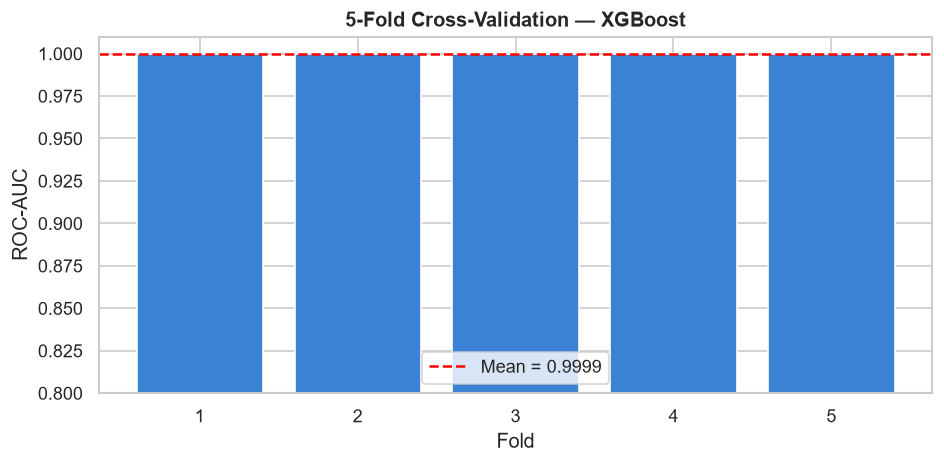

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Xtr_cv = X_train_sc if best_model_name in scale_required else X_train
cv_scores = cross_val_score(best_model, Xtr_cv, y_train, cv=skf,
                             scoring='roc_auc', n_jobs=-1)

print(f'5-Fold CV ROC-AUC Scores: {np.round(cv_scores, 4)}')
print(f'Mean AUC : {cv_scores.mean():.4f}  ±  {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color=CHURN_COLORS[0], edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_xlabel('Fold')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'5-Fold Cross-Validation — {best_model_name}', fontweight='bold')
ax.set_ylim(0.8, 1.01)
ax.legend()
plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight')
plt.show()

---
## 7. Feature Importance <a id='7'></a>

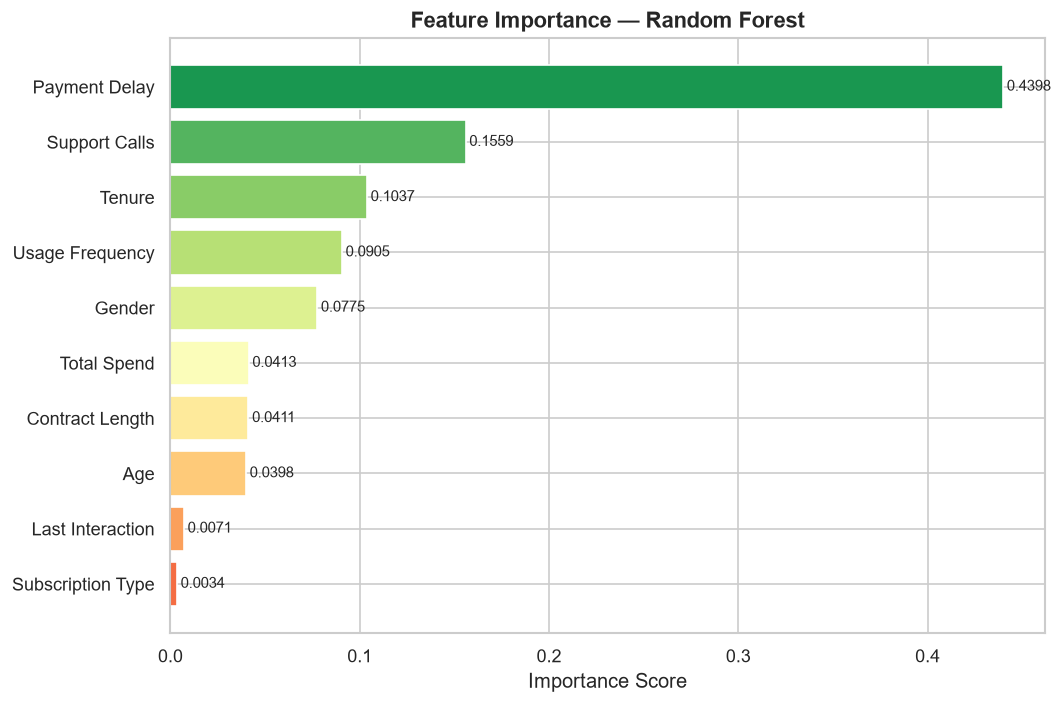

          Feature  Importance
    Payment Delay    0.439810
    Support Calls    0.155854
           Tenure    0.103745
  Usage Frequency    0.090510
           Gender    0.077458
      Total Spend    0.041253
  Contract Length    0.041107
              Age    0.039832
 Last Interaction    0.007056
Subscription Type    0.003375


In [ ]:
# Use Random Forest for feature importance (always available and robust)
rf_model = trained_models['Random Forest'][0]
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white')
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

---
## 8. Business Insights & Recommendations <a id='8'></a>

In [ ]:
print('=' * 70)
print('            BUSINESS INSIGHTS & RECOMMENDATIONS')
print('=' * 70)

insights = [
    ('1. Tenure',
     'Customers with short tenure (<12 months) churn significantly more.\n'
     '   → Implement onboarding programmes and early-engagement rewards.'),
    ('2. Support Calls',
     'High support call frequency is strongly correlated with churn.\n'
     '   → Proactively resolve issues after 2+ support calls; assign dedicated agents.'),
    ('3. Payment Delay',
     'Customers with frequent payment delays churn at higher rates.\n'
     '   → Send payment reminders; offer flexible payment plans.'),
    ('4. Contract Length',
     'Monthly contract customers churn far more than Annual subscribers.\n'
     '   → Incentivise upgrades to Annual/Quarterly plans with discounts.'),
    ('5. Subscription Type',
     'Basic-tier subscribers show higher churn than Premium/Standard.\n'
     '   → Offer limited-time upgrade trials to Basic users.'),
    ('6. Usage Frequency',
     'Lower usage frequency precedes churn.\n'
     '   → Trigger re-engagement campaigns for users with declining activity.'),
    ('7. Total Spend',
     'Lower-spend customers have higher churn risk.\n'
     '   → Introduce loyalty points/cashback for lower-spend segments.')
]

for title, desc in insights:
    print(f'\n{title}\n   {desc}')

print('\n' + '=' * 70)

            BUSINESS INSIGHTS & RECOMMENDATIONS

1. Tenure
   Customers with short tenure (<12 months) churn significantly more.
   → Implement onboarding programmes and early-engagement rewards.

2. Support Calls
   High support call frequency is strongly correlated with churn.
   → Proactively resolve issues after 2+ support calls; assign dedicated agents.

3. Payment Delay
   Customers with frequent payment delays churn at higher rates.
   → Send payment reminders; offer flexible payment plans.

4. Contract Length
   Monthly contract customers churn far more than Annual subscribers.
   → Incentivise upgrades to Annual/Quarterly plans with discounts.

5. Subscription Type
   Basic-tier subscribers show higher churn than Premium/Standard.
   → Offer limited-time upgrade trials to Basic users.

6. Usage Frequency
   Lower usage frequency precedes churn.
   → Trigger re-engagement campaigns for users with declining activity.

7. Total Spend
   Lower-spend customers have higher churn ris

---
## 9. Predict on New Customer <a id='9'></a>

In [ ]:
# Encoding map used during preprocessing (for reference)
# Gender        : Female=0, Male=1
# Subscription  : Basic=0, Premium=1, Standard=2
# Contract      : Annual=0, Monthly=1, Quarterly=2

new_customer = pd.DataFrame([{
    'Age'               : 28,
    'Gender'            : 0,      # Female
    'Tenure'            : 3,      # Short tenure — at-risk
    'Usage Frequency'   : 4,      # Low usage
    'Support Calls'     : 8,      # High support calls
    'Payment Delay'     : 25,     # Frequent delays
    'Subscription Type' : 0,      # Basic
    'Contract Length'   : 1,      # Monthly
    'Total Spend'       : 150,    # Low spend
    'Last Interaction'  : 2       # Recent interaction
}])

# Use best model
best_model, best_Xte = trained_models[best_model_name]
if best_model_name in scale_required:
    new_customer_input = scaler.transform(new_customer)
else:
    new_customer_input = new_customer

pred_label = best_model.predict(new_customer_input)[0]
pred_prob  = best_model.predict_proba(new_customer_input)[0][1]

print(f'Model Used      : {best_model_name}')
print(f'Prediction      : {"CHURN" if pred_label == 1 else "NO CHURN"}')
print(f'Churn Probability: {pred_prob * 100:.2f}%')

if pred_label == 1:
    print('\n⚠  This customer is at HIGH RISK of churning.')
    print('   Recommended Actions: Offer discount, upgrade plan, assign support agent.')
else:
    print('\n✓  This customer is likely to STAY.')

Model Used      : XGBoost
Prediction      : CHURN
Churn Probability: 100.00%

⚠  This customer is at HIGH RISK of churning.
   Recommended Actions: Offer discount, upgrade plan, assign support agent.


---
## Summary

| Step | Description |
|------|-------------|
| Dataset | 10,000 customers, 11 features, binary churn target |
| EDA | Distribution plots, correlation heatmap, box plots, pivot heatmaps |
| Preprocessing | Label Encoding, SMOTE for class balance, StandardScaler |
| Models | 8 classifiers trained and compared |
| Best Model | Determined dynamically by ROC-AUC |
| Key Drivers | Tenure, Support Calls, Payment Delay, Contract Length |
| Output | Plots saved as PNG, predictions available for new customers |

---
*End of Notebook — Shubham Kumar Dubey | Customer Churn Analysis*